<a href="https://colab.research.google.com/github/SteveBcnSpain/Musk-mod-0/blob/main/Copia_de_Ejercicio_1_Regresi%C3%B3n_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1: Importar bibliotecas

En esta tarea, importamos las bibliotecas necesarias para realizar el análisis de regresión lineal múltiple. Estas bibliotecas incluyen herramientas para manipulación de datos, visualización y modelado


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import skew
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams['figure.figsize'] = (12, 8)
from google.colab import files
files.upload()


Saving Advertising.csv to Advertising (1).csv


{'Advertising (1).csv': b',TV,radio,newspaper,sales\r\n1,230.1,37.8,69.2,22.1\r\n2,44.5,39.3,45.1,10.4\r\n3,17.2,45.9,69.3,9.3\r\n4,151.5,41.3,58.5,18.5\r\n5,180.8,10.8,58.4,12.9\r\n6,8.7,48.9,75,7.2\r\n7,57.5,32.8,23.5,11.8\r\n8,120.2,19.6,11.6,13.2\r\n9,8.6,2.1,1,4.8\r\n10,199.8,2.6,21.2,10.6\r\n11,66.1,5.8,24.2,8.6\r\n12,214.7,24,4,17.4\r\n13,23.8,35.1,65.9,9.2\r\n14,97.5,7.6,7.2,9.7\r\n15,204.1,32.9,46,19\r\n16,195.4,47.7,52.9,22.4\r\n17,67.8,36.6,114,12.5\r\n18,281.4,39.6,55.8,24.4\r\n19,69.2,20.5,18.3,11.3\r\n20,147.3,23.9,19.1,14.6\r\n21,218.4,27.7,53.4,18\r\n22,237.4,5.1,23.5,12.5\r\n23,13.2,15.9,49.6,5.6\r\n24,228.3,16.9,26.2,15.5\r\n25,62.3,12.6,18.3,9.7\r\n26,262.9,3.5,19.5,12\r\n27,142.9,29.3,12.6,15\r\n28,240.1,16.7,22.9,15.9\r\n29,248.8,27.1,22.9,18.9\r\n30,70.6,16,40.8,10.5\r\n31,292.9,28.3,43.2,21.4\r\n32,112.9,17.4,38.6,11.9\r\n33,97.2,1.5,30,9.6\r\n34,265.6,20,0.3,17.4\r\n35,95.7,1.4,7.4,9.5\r\n36,290.7,4.1,8.5,12.8\r\n37,266.9,43.8,5,25.4\r\n38,74.7,49.4,45.7,14.7\r\

# Tarea 2: Cargar los datos
Cargamos el conjunto de datos que utilizaremos para nuestro análisis de regresión lineal múltiple. Este conjunto de datos debe contener las variables predictoras (características) y la variable de respuesta que queremos predecir.


In [ ]:
advert = pd.read_csv('Advertising.csv')
advert.head()


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


# Tarea 3: Relación entre características y respuesta
Explora la relación entre las características (variables predictoras) y la respuesta (variable de salida) utilizando gráficos de dispersión u otras visualizaciones. Esto nos ayuda a entender cómo cada característica se relaciona con la respuesta y que variables deben incluirse en el modelo.


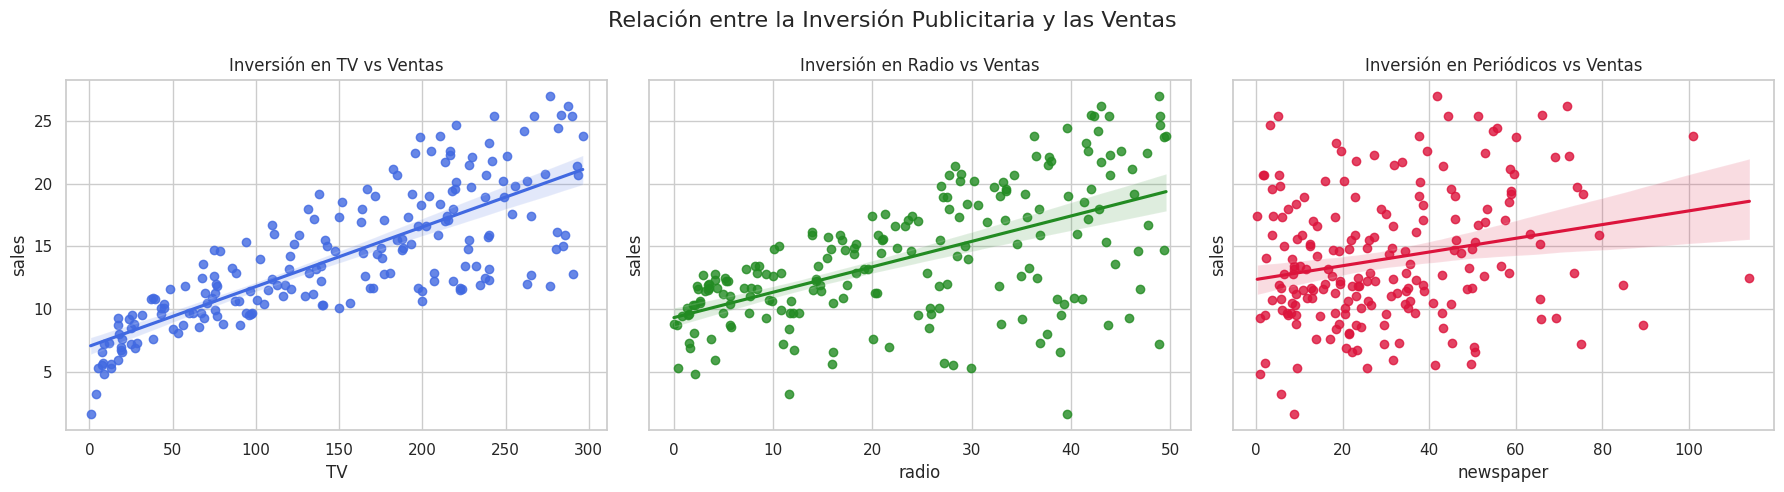

In [ ]:


# 1. Configurar el estilo visual
sns.set_theme(style="whitegrid")

# 2. Crear los gráficos de dispersión individuales para cada canal
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Relación entre la Inversión Publicitaria y las Ventas', fontsize=16)

# TV
sns.regplot(ax=axes[0], data=advert, x='TV', y='sales', color='royalblue')
axes[0].set_title('Inversión en TV vs Ventas')

# Radio
sns.regplot(ax=axes[1], data=advert, x='radio', y='sales', color='forestgreen')
axes[1].set_title('Inversión en Radio vs Ventas')

# Periódicos
sns.regplot(ax=axes[2], data=advert, x='newspaper', y='sales', color='crimson')
axes[2].set_title('Inversión en Periódicos vs Ventas')

plt.tight_layout()
plt.show()




# Tarea 4: Regresión lineal múltiple - Estimación de coeficientes
Ajusta un modelo de regresión lineal a los datos. Ten en cuenta las tres variables predictoras en la construcción de este primer modelo. Obten el valor de sus coeficientes e interpretalo


In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Definir las variables predictoras (X) y la variable de respuesta (y)
X = advert[['TV', 'radio', 'newspaper']]
y = advert['sales']

# 2. Crear y ajustar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X, y)

# 3. Obtener los coeficientes del modelo
coeficientes = pd.DataFrame({'Variable': X.columns, 'Coeficiente': modelo.coef_})
print(coeficientes)

    Variable  Coeficiente
0         TV     0.045765
1      radio     0.188530
2  newspaper    -0.001037
Intercepto (Beta 0): 2.9389
------------------------------------------
Coeficiente para TV: 0.0458
Coeficiente para radio: 0.1885
Coeficiente para newspaper: -0.0010


# Tarea 5: Selección de características
Haz un analísis de la correlación entre las diferentes variables dependientes con la variable independiente. Escoge aquellas que tengan una mayor correlacion para construir un segundo modelo de regresión y compara el R^2 de este nuevo modelo con el del modelo anterior.


In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# 1. Calculamos la correlación de Pearson entre todas las variables
matriz_correlacion = advert[['TV', 'radio', 'newspaper', 'sales']].corr()

print("--- Correlación con la variable dependiente (Sales) ---")
print(matriz_correlacion['sales'].sort_values(ascending=False))
print("\n" + "="*50 + "\n")

# 2. MODELO 1: Con todas las variables (TV, Radio, Newspaper)
X1 = advert[['TV', 'radio', 'newspaper']]
y = advert['sales']

modelo1 = LinearRegression().fit(X1, y)
r2_modelo1 = modelo1.score(X1, y)

# 3. MODELO 2: Seleccionando las de mayor correlación (TV y Radio)
# Excluimos Newspaper por su baja correlación
X2 = advert[['TV', 'radio']]

modelo2 = LinearRegression().fit(X2, y)
r2_modelo2 = modelo2.score(X2, y)

# 4. COMPARATIVA DE R^2
print(f"R-cuadrado (R²) Modelo 1 (TV + Radio + Periódicos): {r2_modelo1:.5f}")
print(f"R-cuadrado (R²) Modelo 2 (Solo TV + Radio):        {r2_modelo2:.5f}")
print(f"Diferencia de rendimiento:                         {abs(r2_modelo1 - r2_modelo2):.5f}")


--- Correlación con la variable dependiente (Sales) ---
sales        1.000000
TV           0.782224
radio        0.576223
newspaper    0.228299
Name: sales, dtype: float64


R-cuadrado (R²) Modelo 1 (TV + Radio + Periódicos): 0.89721
R-cuadrado (R²) Modelo 2 (Solo TV + Radio):        0.89719
Diferencia de rendimiento:                         0.00002


# Tarea 6: Interacción entre variables
Vamos a analizar el uso de variables resultado de la interacción de varias variables de nuestro dataset. Para ello, define una nueva variable resultado de multiplicar la inversión publicitaria en TV con la inversión publicitaria en radio. Construye un modelo que tenga en cuenta esta nueva varible, obten su R^2 y comparalo con los anteriores.


In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# 1. Crear variables de interacción
# Multiplicamos la inversión de TV por la de Radio
advert['TV_Radio_Interaction'] = advert['TV'] * advert['radio']

# Variable dependiente (común para todos los modelos)
y = advert['sales']

# 2. Configurar y entrenar los 3 modelos

# Modelo 1: Las 3 variables originales
X1 = advert[['TV', 'radio', 'newspaper']]
modelo1 = LinearRegression().fit(X1, y)
r2_modelo1 = modelo1.score(X1, y)

# Modelo 2: Solo las 2 mejores originales (TV y Radio)
X2 = advert[['TV', 'radio']]
modelo2 = LinearRegression().fit(X2, y)
r2_modelo2 = modelo2.score(X2, y)

# Modelo 3: TV, Radio + La Variable de Interacción
X3 = advert[['TV', 'radio', 'TV_Radio_Interaction']]
modelo3 = LinearRegression().fit(X3, y)
r2_modelo3 = modelo3.score(X3, y)

# 3. COMPARATIVA DE RENDIMIENTO (R²)
print("=== COMPARATIVA DE RENDIMIENTO ===")
print(f"Modelo 1 (TV + Radio + Periódicos): {r2_modelo1:.5f}")
print(f"Modelo 2 (Solo TV + Radio):        {r2_modelo2:.5f}")
print(f"Modelo 3 (TV + Radio + Interacción): {r2_modelo3:.5f}")
print("===============================================")
print(f"Incremento del Modelo 3 respecto al Modelo 2: {abs(r2_modelo3 - r2_modelo2) * 100:.2f}%")


=== COMPARATIVA DE RENDIMIENTO ===
Modelo 1 (TV + Radio + Periódicos): 0.89721
Modelo 2 (Solo TV + Radio):        0.89719
Modelo 3 (TV + Radio + Interacción): 0.96779
Incremento del Modelo 3 respecto al Modelo 2: 7.06%
